In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

In [11]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = F.relu(self.fc2(z))
        x_recon = torch.sigmoid(self.fc3(h))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


In [3]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return bce + kld, bce, kld


In [12]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_vae_MNIST = VAE().to(device)

optimizer = torch.optim.Adam(model_vae_MNIST.parameters(), lr=1e-3)

cpu


In [6]:
num_epochs = 30
train_losses = []
bce_losses = []
kld_losses = []

In [ ]:
for epoch in range(num_epochs):

    model_vae_MNIST.train()

    running_loss = 0
    running_bce = 0
    running_kld = 0

    for x, _ in train_loader:

        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model_vae_MNIST(x)

        loss, bce, kld = vae_loss(recon, x, mu, logvar)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    train_losses.append(running_loss / len(train_loader))
    bce_losses.append(running_bce / len(train_loader))
    kld_losses.append(running_kld / len(train_loader))

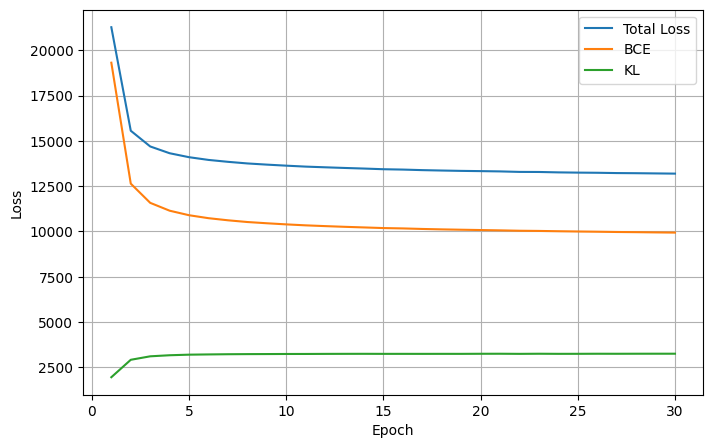

In [8]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_epochs+1), train_losses, label="Total Loss")
plt.plot(range(1, num_epochs+1), bce_losses, label="BCE")
plt.plot(range(1, num_epochs+1), kld_losses, label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
model_vae_MNIST.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    recon, _, _ = model_vae_MNIST(images)

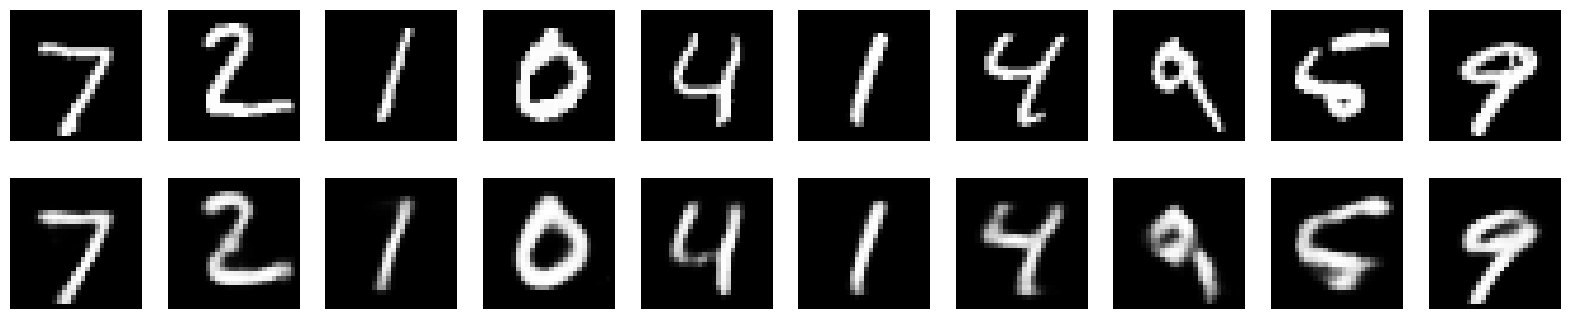

In [10]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # تصویر واقعی
    plt.subplot(2,n,i+1)
    plt.imshow(images[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

    # تصویر بازسازی شده
    plt.subplot(2,n,i+n+1)
    plt.imshow(recon[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

plt.show()

In [11]:
model_vae_MNIST.eval()

with torch.no_grad():

    z = torch.randn(10,20).to(device)

    generated = model_vae_MNIST.decode(z)

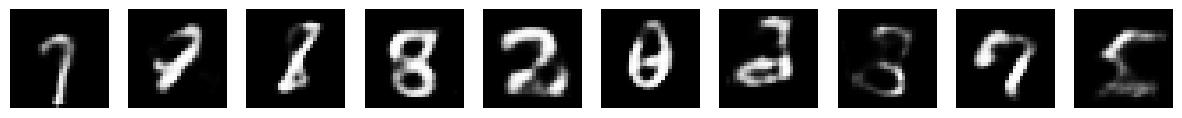

In [12]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28), cmap="gray")

    plt.axis("off")

plt.show()

In [13]:
latent = []

labels = []

model_vae_MNIST.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.view(-1,784).to(device)

        mu, logvar = model_vae_MNIST.encode(x)

        latent.append(mu.cpu())

        labels.append(y)

In [14]:
latent = torch.cat(latent)
labels = torch.cat(labels)

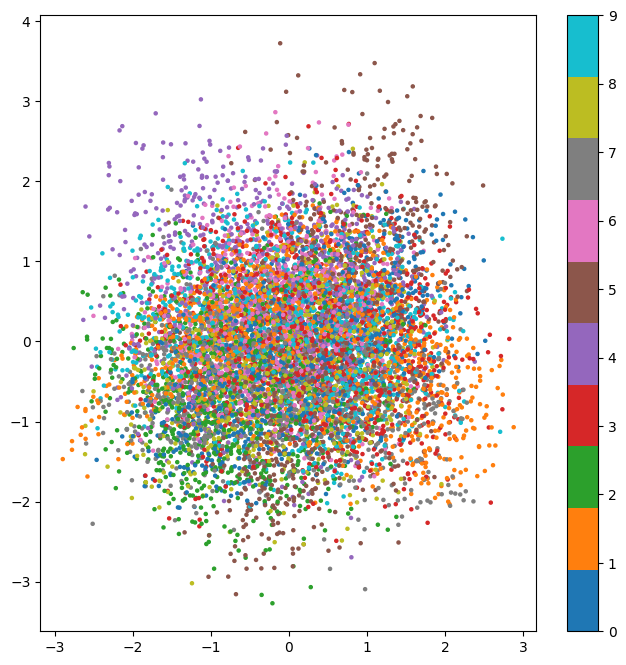

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(latent[:,0],
            latent[:,1],
            c=labels,
            s=5,
            cmap="tab10")

plt.colorbar()

plt.show()

In [17]:
tsne = TSNE(n_components=2)
latent_2d = tsne.fit_transform(latent)

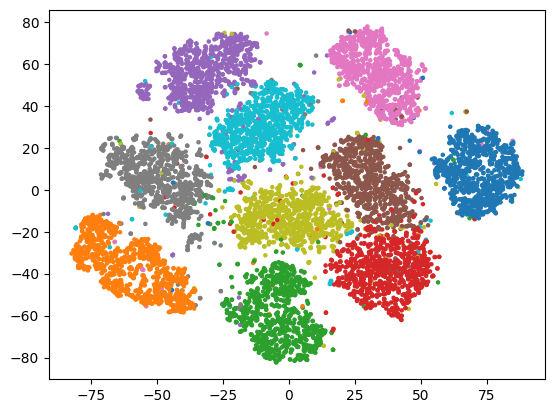

In [18]:
plt.scatter(latent_2d[:,0],
            latent_2d[:,1],
            c=labels,
            s=5,
            cmap="tab10")

In [ ]:
# def weight_reset(m):
#     if hasattr(m, 'reset_parameters'):
#         m.reset_parameters()
# model_vae_Fashion.apply(weight_reset)

In [22]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 26.4M/26.4M [00:16<00:00, 1.62MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 590kB/s]


In [23]:
model_vae_Fashion = VAE().to(device)

optimizer = torch.optim.Adam(model_vae_Fashion.parameters(), lr=1e-3)

In [56]:
num_epochs = 30
train_losses = []
bce_losses = []
kld_losses = []

In [57]:
for epoch in range(num_epochs):

    model_vae_Fashion.train()

    running_loss = 0
    running_bce = 0
    running_kld = 0

    for x, _ in train_loader:

        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model_vae_Fashion(x)

        loss, bce, kld = vae_loss(recon, x, mu, logvar)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    train_losses.append(running_loss / len(train_loader))
    bce_losses.append(running_bce / len(train_loader))
    kld_losses.append(running_kld / len(train_loader))

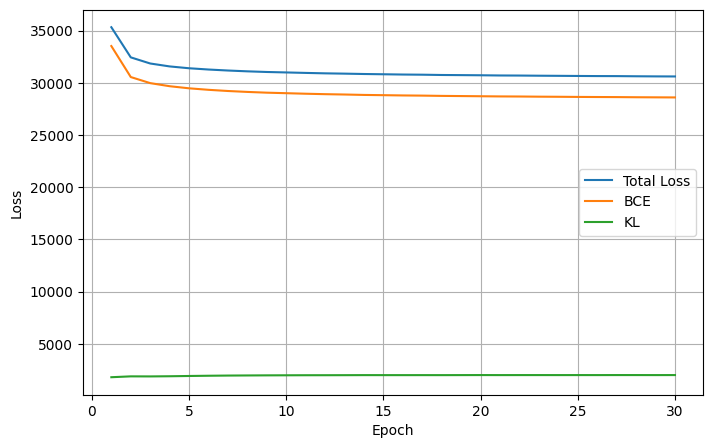

In [58]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_epochs+1), train_losses, label="Total Loss")
plt.plot(range(1, num_epochs+1), bce_losses, label="BCE")
plt.plot(range(1, num_epochs+1), kld_losses, label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [59]:
model_vae_Fashion.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    recon, _, _ = model_vae_Fashion(images)

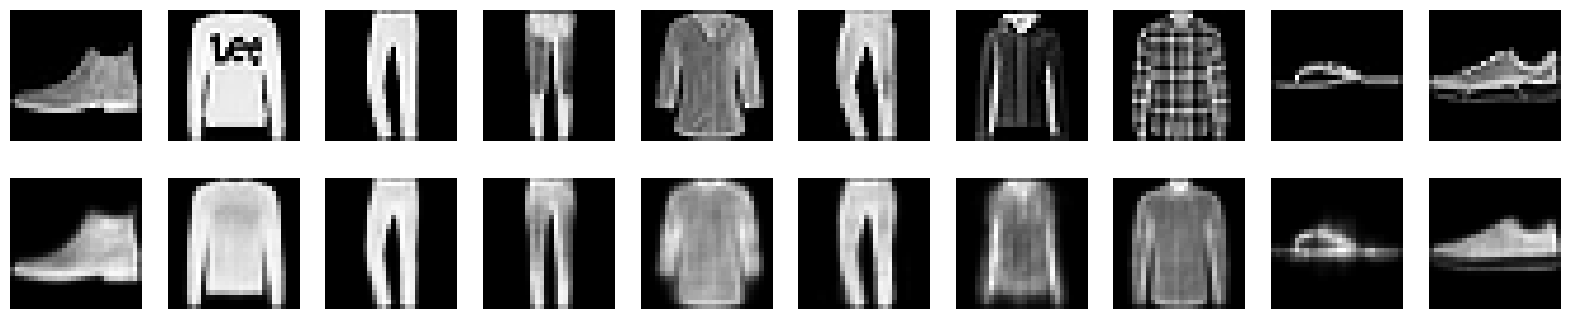

In [60]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # تصویر واقعی
    plt.subplot(2,n,i+1)
    plt.imshow(images[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

    # تصویر بازسازی شده
    plt.subplot(2,n,i+n+1)
    plt.imshow(recon[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

plt.show()

In [61]:
model_vae_Fashion.eval()

with torch.no_grad():

    z = torch.randn(10,20).to(device)

    generated = model_vae_Fashion.decode(z)

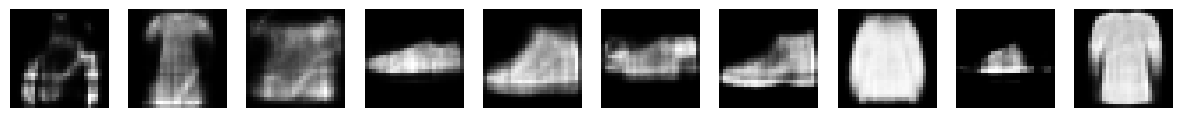

In [62]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28), cmap="gray")

    plt.axis("off")

plt.show()

# CVEA

In [14]:
class CVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20, num_classes=10):
        super(CVAE, self).__init__()
        self.num_classes = num_classes

        self.fc1 = nn.Linear(input_dim + num_classes, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim + num_classes, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, y):
        x = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        z = torch.cat([z, y], dim=1)
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, y)
        return recon_x, mu, logvar


In [15]:
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()


In [16]:
model_CVAE_MNIST = CVAE(input_dim=784, hidden_dim=400, latent_dim=20, num_classes=10).to(device)
optimizer = torch.optim.Adam(model_CVAE_MNIST.parameters(), lr=1e-3)

In [17]:
num_epochs = 30
train_losses = []
bce_losses = []
kld_losses = []

In [18]:
for epoch in range(num_epochs):

    model_CVAE_MNIST.train()

    running_loss = 0
    running_bce = 0
    running_kld = 0

    for x, y in train_loader:

        x = x.view(-1,784).to(device)

        y = y.to(device)
        y_onehot = one_hot(y).to(device)

        optimizer.zero_grad()

        recon_x, mu, logvar = model_CVAE_MNIST(x, y_onehot)

        loss, bce, kld = vae_loss(recon_x, x, mu, logvar)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    train_losses.append(running_loss/len(train_dataset))
    bce_losses.append(running_bce/len(train_dataset))
    kld_losses.append(running_kld/len(train_dataset))


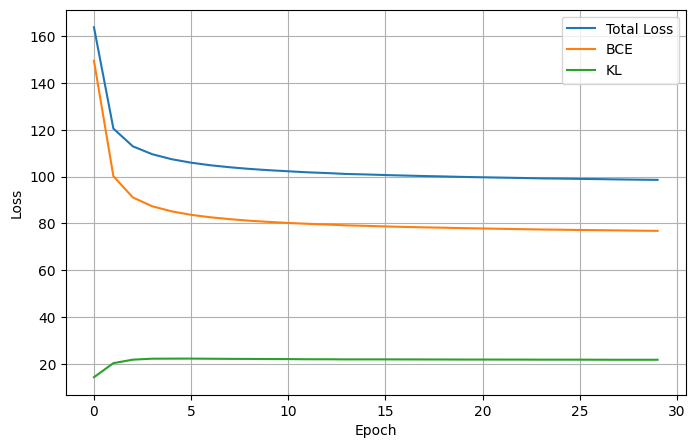

In [19]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Total Loss")
plt.plot(bce_losses,label="BCE")
plt.plot(kld_losses,label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Conditional Generation

In [35]:
model_CVAE_MNIST.eval()

with torch.no_grad():

    n = 10

    z = torch.randn(n,20).to(device)

    labels = torch.full((n,),6).to(device)

    labels = one_hot(labels).to(device)

    generated = model_CVAE_MNIST.decode(z,labels)

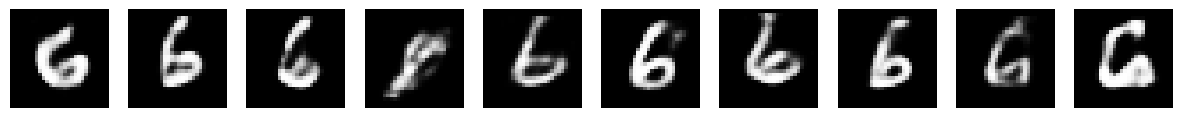

In [36]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28),
               cmap="gray")

    plt.axis("off")

plt.show()

In [40]:
model_CVAE_MNIST.eval()

with torch.no_grad():

    labels = torch.arange(10).to(device)

    z = torch.randn(10,20).to(device)

    labels = one_hot(labels).to(device)

    generated = model_CVAE_MNIST.decode(z, labels)

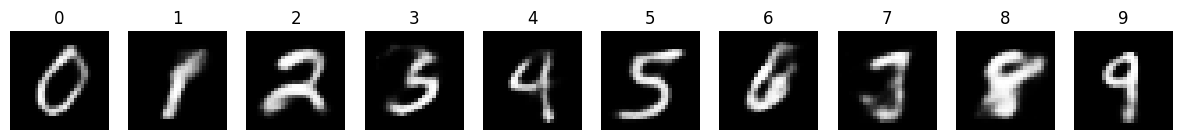

In [41]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28), cmap="gray")

    plt.title(str(i))
    plt.axis("off")

plt.show()

In [42]:
model_CVAE_MNIST.eval()

with torch.no_grad():

    images,labels = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    labels = one_hot(labels).to(device)

    recon,_,_ = model_CVAE_MNIST(images,labels)

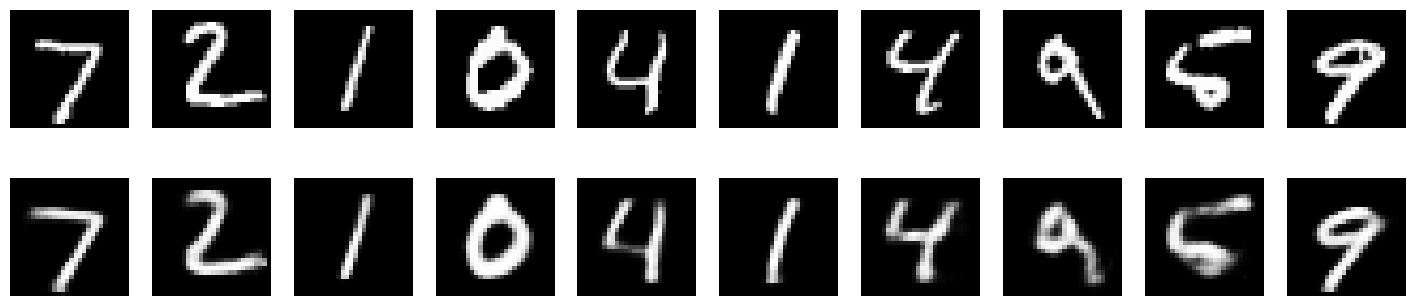

In [43]:
n=10

plt.figure(figsize=(18,4))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(images[i].cpu().view(28,28),
               cmap="gray")
    plt.axis("off")

    plt.subplot(2,n,i+n+1)
    plt.imshow(recon[i].cpu().view(28,28),
               cmap="gray")
    plt.axis("off")

plt.show()

# Conditional Generation with wrong_labels and input_image  

In [44]:
model_CVAE_MNIST.eval()

with torch.no_grad():

    images,labels = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    labels = labels.to(device)

    original_label = one_hot(labels).to(device)

    mu,logvar = model_CVAE_MNIST.encode(images,
                             original_label)

    z = model_CVAE_MNIST.reparameterize(mu,logvar)
    
    wrong_labels = torch.full_like(labels,8)

    wrong_labels = one_hot(wrong_labels).to(device)

    transferred = model_CVAE_MNIST.decode(z, wrong_labels)

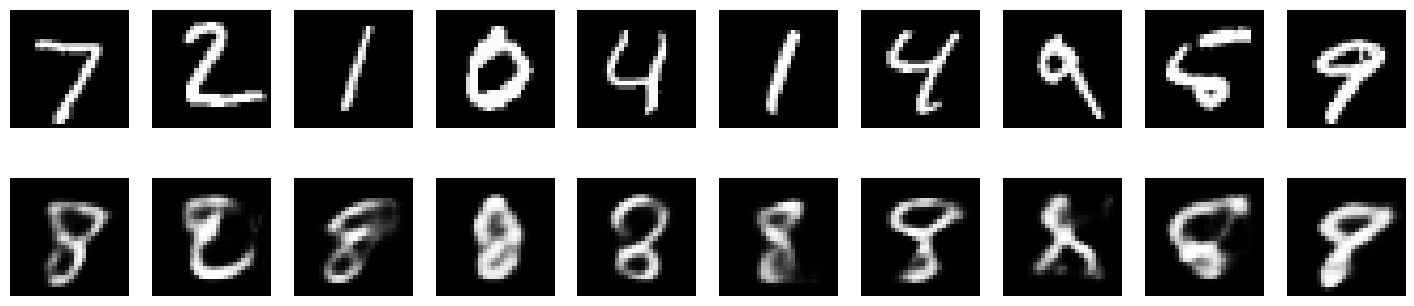

In [45]:
n=10

plt.figure(figsize=(18,4))

for i in range(n):

    plt.subplot(2,n,i+1)

    plt.imshow(images[i].cpu().view(28,28),
               cmap="gray")

    plt.axis("off")

    plt.subplot(2,n,i+n+1)

    plt.imshow(transferred[i].cpu().view(28,28),
               cmap="gray")

    plt.axis("off")

plt.show()

In [48]:
model_CVAE_MNIST.eval()

with torch.no_grad():
    idx = 0

    image = images[idx:idx+1]

    label = labels[idx:idx+1]

    label_onehot = one_hot(label).to(device)

    mu,logvar = model_CVAE_MNIST.encode(image,
                            label_onehot)

    z = model_CVAE_MNIST.reparameterize(mu,
                            logvar)

    new_label = torch.tensor([5]).to(device)

    new_label = one_hot(new_label).to(device)

    result = model_CVAE_MNIST.decode(z,
                        new_label)

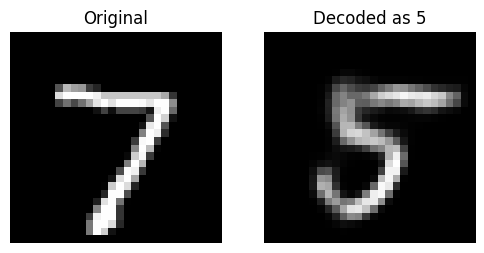

In [49]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)

plt.imshow(image.cpu().view(28,28),
           cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(result.cpu().view(28,28),
           cmap="gray")

plt.title("Decoded as 5")

plt.axis("off")

plt.show()